# B4A jeepney RL analysis
This notebook keeps the geometric seed routes and the passenger scoring stack separate from PPO training so we can inspect the starting route spectrum first.


## 1. Traffic-biased quadrilateral baselines
We start from the physical street network only, because the 3-layer graph is reserved for evaluation.


In [1]:

import math
import secrets
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, IFrame, display
from shapely.geometry import Polygon
from tqdm.auto import tqdm

from _bootstrap import ROOT
from utils import (
    BaselineRoute,
    BaselineRouteGenerator,
    JeepneyRouteEnv,
    JeepneySystem,
    SystemicFitnessEvaluator,
    build_route_notes as build_route_spectrum_notes,
    build_route_spectrum_frame,
    calculate_route_fitness,
    compare_route_spectrum_frames,
    make_coord_key,
    plot_correlation_delta,
    plot_correlation_heatmap,
    route_correlation_pairs,
    route_spectrum_correlation,
    summarize_route_spectrum,
    train_route_agent,
)

OUTPUT_DIR = Path(ROOT) / "results" / "B4A_jeepney_rl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_ROUTES = 20
random_seed = secrets.randbits(32)

generator = BaselineRouteGenerator(
    min_area_m2=2_000_000,
    anchor_pool_size=96,
    max_attempts=500,
    seed=random_seed,
)
routes = generator.generate_routes(NUM_ROUTES, route_prefix="B4A", seed=random_seed)
route_system = JeepneySystem.from_routes(routes)
summary = pd.DataFrame(
    [
        {
            "route_id": route.route_id,
            "anchors": list(route.ordered_anchor_node_ids),
            "area_m2": round(route.polygon_area_m2, 0),
            "length_m": round(route.path_length_m, 0),
            "attempt": route.attempt_index,
        }
        for route in routes
    ]
)
summary.to_csv(OUTPUT_DIR / "B4A_pre_training_routes.csv", index=False)
summary


c:\Users\lifei\OneDrive\Desktop\Thesis\Thesis Repository\Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,route_id,anchors,area_m2,length_m,attempt
0,B4A01,"[81, 2473, 61, 953]",11423137.0,57199.0,1
1,B4A02,"[299, 363, 1184, 37]",25000095.0,59111.0,1
2,B4A03,"[941, 1491, 592, 2733]",52588250.0,61371.0,1
3,B4A04,"[737, 363, 873, 1102]",8647292.0,23745.0,1
4,B4A05,"[3073, 2101, 2122, 1776]",2423803.0,33909.0,1
5,B4A06,"[3131, 755, 79, 105]",25407829.0,49791.0,1
6,B4A07,"[286, 123, 1382, 1383]",2064419.0,26385.0,1
7,B4A08,"[1169, 49, 452, 1298]",8564710.0,24077.0,1
8,B4A09,"[3241, 3523, 363, 196]",47448502.0,46401.0,1
9,B4A10,"[486, 522, 101, 2378]",3952106.0,22775.0,1


## 2. RL environment and state embeddings
This is a quick sanity check on the coordinate-relative observation space the policy will see later.


In [2]:

np.set_printoptions(precision=3, suppress=True)
env = JeepneyRouteEnv(
    drive_graph_raw=generator.drive_graph_raw,
    drive_graph_proj=generator.drive_graph_proj,
    seed=random_seed,
    max_steps=12,
)

def print_observation(obs: dict[str, np.ndarray]) -> None:
    print('shape:', obs['shape'])
    print('history:', obs['history'])
    print('topology:', obs['topology'])
    print('demand:', obs['demand'])
    print('global:', obs['global'])
    print('candidates:')
    for candidate_index, row in enumerate(obs['candidates']):
        print(f'  {candidate_index}: {row}')
    print('mask:', obs['action_mask'])

obs, info = env.reset()
print('reset state vector length:', info['state_vector'].shape[0])
print_observation(obs)

rng = np.random.default_rng(random_seed)
for step_index in range(5):
    valid_actions = np.flatnonzero(obs['action_mask'][:-1])
    action = int(rng.choice(valid_actions)) if len(valid_actions) else env.max_candidates
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"step {step_index + 1}: action={action}, reward={reward:.3f}, terminated={terminated}, truncated={truncated}")
    print('turn angle rad:', info['turn_angle_rad'])
    print('sinuosity index:', info['sinuosity_index'])
    print('distance to origin m:', info['distance_to_origin_m'])
    print('bearing to origin rad:', info['bearing_to_origin_rad'])
    print('route area m2:', info['route_area_m2'])
    print('state vector:', info['state_vector'])
    print_observation(obs)
    if terminated or truncated:
        break


reset state vector length: 91
shape: [0. 0. 1. 0. 0. 0. 0.]
history: [0. 0. 0. 0. 0. 0. 0. 0.]
topology: [0.5   0.5   0.    0.5   0.389]
demand: [0.22  0.268 0.348 0.128]
global: [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.5   0.5   0.    0.5   0.389 0.22  0.268 0.348 0.128]
candidates:
  0: [-0.136 -0.991  0.008  0.333  0.     0.229  0.008  0.     1.     0.   ]
  1: [-0.132  0.991  0.009  0.333  0.     0.348  0.128  0.     0.     0.   ]
  2: [0.992 0.125 0.004 0.5   0.    0.228 0.008 0.    0.    0.   ]
  3: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  4: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  5: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
mask: [1. 1. 1. 0. 0. 0. 1.]
step 1: action=0, reward=-0.000, terminated=False, truncated=False
turn angle rad: 0.0
sinuosity index: 1.0
distance to origin m: 51.85564083952288
bearing to origin rad: 3.141592653589793
route area m2: 0.0
state vector: [ 0.001  0.    -1.     0.001  0.001  0.     0.     0.     0.     0.
  0.     1.   

## 3. Reward signal on the layered graph
The route score comes from passenger generalized travel cost on the 3-layer evaluation graph.


Scoring pre-training routes: 100%|██████████| 20/20 [00:32<00:00,  1.62s/it]


C:\Users\lifei\OneDrive\Desktop\Thesis\Thesis Repository\Thesis\results\B4A_jeepney_rl\B4A_route_explorer.html


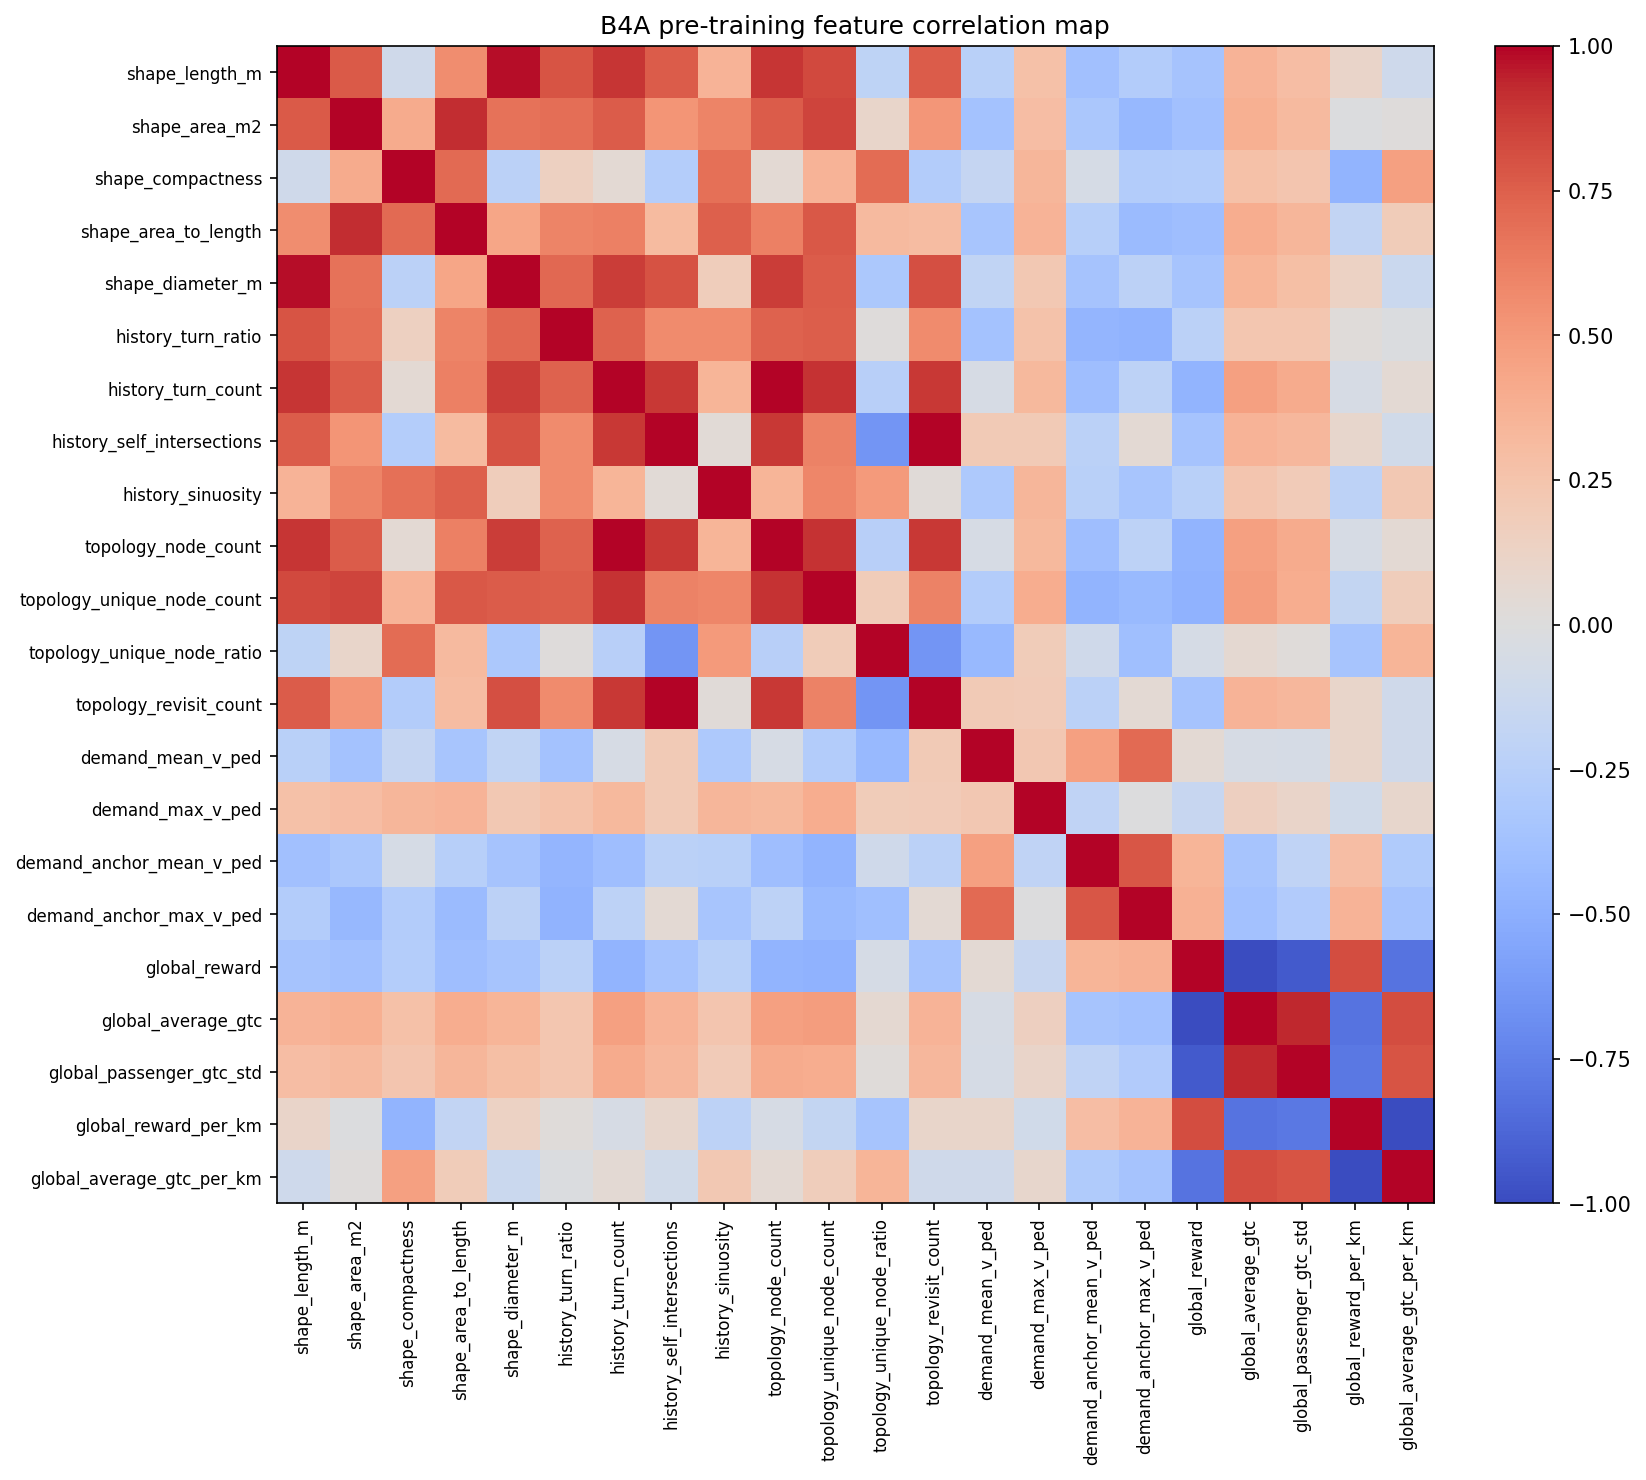

,feature_a,feature_b,correlation
0,global_reward_per_km,global_average_gtc_per_km,-1.000000
1,global_reward,global_average_gtc,-1.000000
2,history_turn_count,topology_node_count,1.000000
3,history_self_intersections,topology_revisit_count,0.999693
4,shape_length_m,shape_diameter_m,0.980016
5,global_average_gtc,global_passenger_gtc_std,0.934501
6,global_reward,global_passenger_gtc_std,-0.934501
7,shape_area_m2,shape_area_to_length,0.921498
8,history_turn_count,topology_unique_node_count,0.901099
9,topology_node_count,topology_unique_node_count,0.901099


B4A pre-training: 20 routes
means | reward=-6737.725, avg_gtc=6737.725, gtc_std=9887.564, length_m=46789.6, area_m2=31116743.3
spread | reward_std=6426.104, avg_gtc_std=6426.104, sinuosity_mean=2.652, demand_mean=1.683
top | global_reward: global_average_gtc (-1.00), global_passenger_gtc_std (-0.93), global_reward_per_km (+0.82)
top | global_average_gtc: global_reward (-1.00), global_passenger_gtc_std (+0.93), global_reward_per_km (-0.82)
top | global_passenger_gtc_std: global_reward (-0.93), global_average_gtc (+0.93), global_reward_per_km (-0.79)


In [3]:

route_edges = pd.DataFrame(
    [(int(u), int(v), 'start_walk') for u, v in generator.drive_graph_raw.edges()],
    columns=['u', 'v', 'edge_type'],
)
route_manager = SimpleNamespace(
    edges=route_edges,
    _node_coords={
        int(row.base_node_id): (float(row.lat), float(row.lon))
        for row in generator.node_table.itertuples(index=False)
    },
)
raw_latlon_by_node = {
    int(node_id): (float(data.get('y', 0.0)), float(data.get('x', 0.0)))
    for node_id, data in generator.drive_graph_raw.nodes(data=True)
}
proj_xy_by_node = {
    int(node_id): (float(data.get('x', 0.0)), float(data.get('y', 0.0)))
    for node_id, data in generator.drive_graph_proj.nodes(data=True)
}


def build_route_encoding(route_id: str) -> str:
    return f'route_id: {route_id}'


def interpret_embeddings(route: BaselineRoute) -> str:
    route_path = route.path_node_ids
    if not route_path or len(route_path) < 2:
        return 'Route too short to analyze.'

    lines: list[str] = []
    area = route.polygon_area_m2
    length = route.path_length_m
    area_to_length = area / max(length, 1.0)

    if area_to_length > 1000:
        lines.append('shape: Compact, efficient use of space')
    elif area_to_length > 200:
        lines.append('shape: Moderate coverage relative to distance')
    else:
        lines.append('shape: Linear route with extended length')

    node_count = len(route_path)
    if node_count > 50:
        lines.append('topology: High node density, complex route structure')
    elif node_count > 25:
        lines.append('topology: Moderate complexity with multiple waypoints')
    else:
        lines.append('topology: Simple, direct route path')

    if area > 50_000_000:
        lines.append('demand: Large service area, potentially high demand coverage')
    elif area > 10_000_000:
        lines.append('demand: Medium service area with moderate demand potential')
    else:
        lines.append('demand: Compact service area with focused demand')

    if len(route.path_latlon) >= 2:
        start = route.path_latlon[0]
        end = route.path_latlon[-1]
        straight_dist = math.sqrt((end[0] - start[0]) ** 2 + (end[1] - start[1]) ** 2) * 111000
        sinuosity = length / max(straight_dist, 1.0)
        if sinuosity > 1.5:
            lines.append('history: Winding route with many turns')
        elif sinuosity > 1.1:
            lines.append('history: Moderate turning pattern')
        else:
            lines.append('history: Direct path with minimal deviations')

    return '\n'.join(lines) if lines else 'No embedding data available.'


def route_signature(route: BaselineRoute) -> tuple[int, ...]:
    return tuple(int(node_id) for node_id in route.path_node_ids)


def route_notes(route: BaselineRoute, fitness, tag: str) -> dict[str, str]:
    return {
        'encoding': build_route_encoding(route.route_id),
        'interpretation': (
            f'{tag} reward={fitness.reward:.3f} | avg_gtc={fitness.average_gtc:.3f} | ' +
            f'gtc_std={fitness.passenger_gtc_std:.3f}\n\n{interpret_embeddings(route)}'
        ),
    }

def score_route(route: BaselineRoute, *, seed_offset: int = 0, batch_size: int = 5):
    return calculate_route_fitness(
        route.path_node_ids,
        passenger_map=generator.passenger_map,
        drive_graph_raw=generator.drive_graph_raw,
        drive_graph_proj=generator.drive_graph_proj,
        seed=random_seed + seed_offset,
        batch_size=batch_size,
    )


def build_route_metrics(routes: list[BaselineRoute], *, label: str, batch_size: int = 5) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for index, route in enumerate(tqdm(routes, desc=f'Scoring {label} routes')):
        fitness = score_route(route, seed_offset=index, batch_size=batch_size)
        rows.append(
            {
                'route_id': route.route_id,
                'reward': round(float(fitness.reward), 3),
                'average_gtc': round(float(fitness.average_gtc), 3),
                'std_gtc': round(float(fitness.passenger_gtc_std), 3),
                'route_length_m': round(float(route.path_length_m), 3),
                'route_area_m2': round(float(route.polygon_area_m2), 3),
                'node_count': len(route.path_node_ids),
            }
        )
    return pd.DataFrame(rows)


def export_route_spectrum(routes: list[BaselineRoute], metrics: pd.DataFrame, *, output_html: Path, title: str, tag: str) -> Path:
    route_lookup = {route.route_id: route for route in routes}
    notes = {
        row.route_id: route_notes(route_lookup[row.route_id], score_route(route_lookup[row.route_id], seed_offset=i), tag)
        for i, row in enumerate(metrics.itertuples(index=False))
    }
    html_path = route_system.export_route_toggle_html(route_manager, output_html, title=title, route_notes=notes)
    return html_path


def plot_route_spectrum(pre_df: pd.DataFrame, post_df: pd.DataFrame, output_png: Path, *, title: str) -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].scatter(pre_df['average_gtc'], pre_df['std_gtc'], label='pre', alpha=0.75, s=35)
    axes[0].scatter(post_df['average_gtc'], post_df['std_gtc'], label='post', alpha=0.75, s=35)
    axes[0].set_xlabel('Average GTC')
    axes[0].set_ylabel('Passenger GTC std')
    axes[0].set_title('GTC vs stability')
    axes[0].legend()

    axes[1].hist(pre_df['reward'], bins=10, alpha=0.6, label='pre')
    axes[1].hist(post_df['reward'], bins=10, alpha=0.6, label='post')
    axes[1].set_xlabel('Reward')
    axes[1].set_ylabel('Count')
    axes[1].set_title(title)
    axes[1].legend()

    output_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_png, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return output_png

passenger_vped_lookup = generator.passenger_map.df.copy()
passenger_vped_lookup["coord_key"] = make_coord_key(passenger_vped_lookup, "lon", "lat")
passenger_vped_lookup = passenger_vped_lookup.groupby("coord_key")["v_ped"].mean().astype(float).to_dict()
node_vped_lookup = {
    int(row.base_node_id): float(passenger_vped_lookup.get(row.coord_key, 0.0))
    for row in generator.node_table.itertuples(index=False)
}

pre_metrics = build_route_metrics(routes, label='pre-training')
pre_metrics.to_csv(OUTPUT_DIR / 'B4A_pre_training_route_metrics.csv', index=False)
pre_frame = build_route_spectrum_frame(
    routes,
    score_route_fn=lambda route, index: score_route(route, seed_offset=index),
    node_vped_lookup=node_vped_lookup,
    phase='B4A pre-training',
)
pre_summary = summarize_route_spectrum(pre_frame, label='B4A pre-training')
pre_corr = route_spectrum_correlation(pre_frame)
pre_corr_pairs = route_correlation_pairs(pre_corr, limit=12, min_abs=0.35)
pre_route_notes = build_route_spectrum_notes(routes, pre_frame, phase='B4A pre-training')
pre_frame.to_csv(OUTPUT_DIR / 'B4A_pre_training_feature_frame.csv', index=False)
pre_corr.to_csv(OUTPUT_DIR / 'B4A_pre_training_correlations.csv')
pre_corr_png = plot_correlation_heatmap(
    pre_corr,
    OUTPUT_DIR / 'B4A_pre_training_correlation_heatmap.png',
    title='B4A pre-training feature correlation map',
)
html_path = route_system.export_route_toggle_html(
    route_manager,
    OUTPUT_DIR / 'B4A_route_explorer.html',
    title=f'B4A Jeepney Routes ({NUM_ROUTES})',
    route_notes=pre_route_notes,
    overall_summary=pre_summary,
)
print(html_path)
display(IFrame(html_path.as_uri(), width=1200, height=900))
display(Image(filename=str(pre_corr_png)))
display(pre_corr_pairs)
print(pre_summary)


## 4. Pre-training correlation spectrum
We score the baseline routes, map the feature relationships, and keep the route explorer focused on the overall findings.


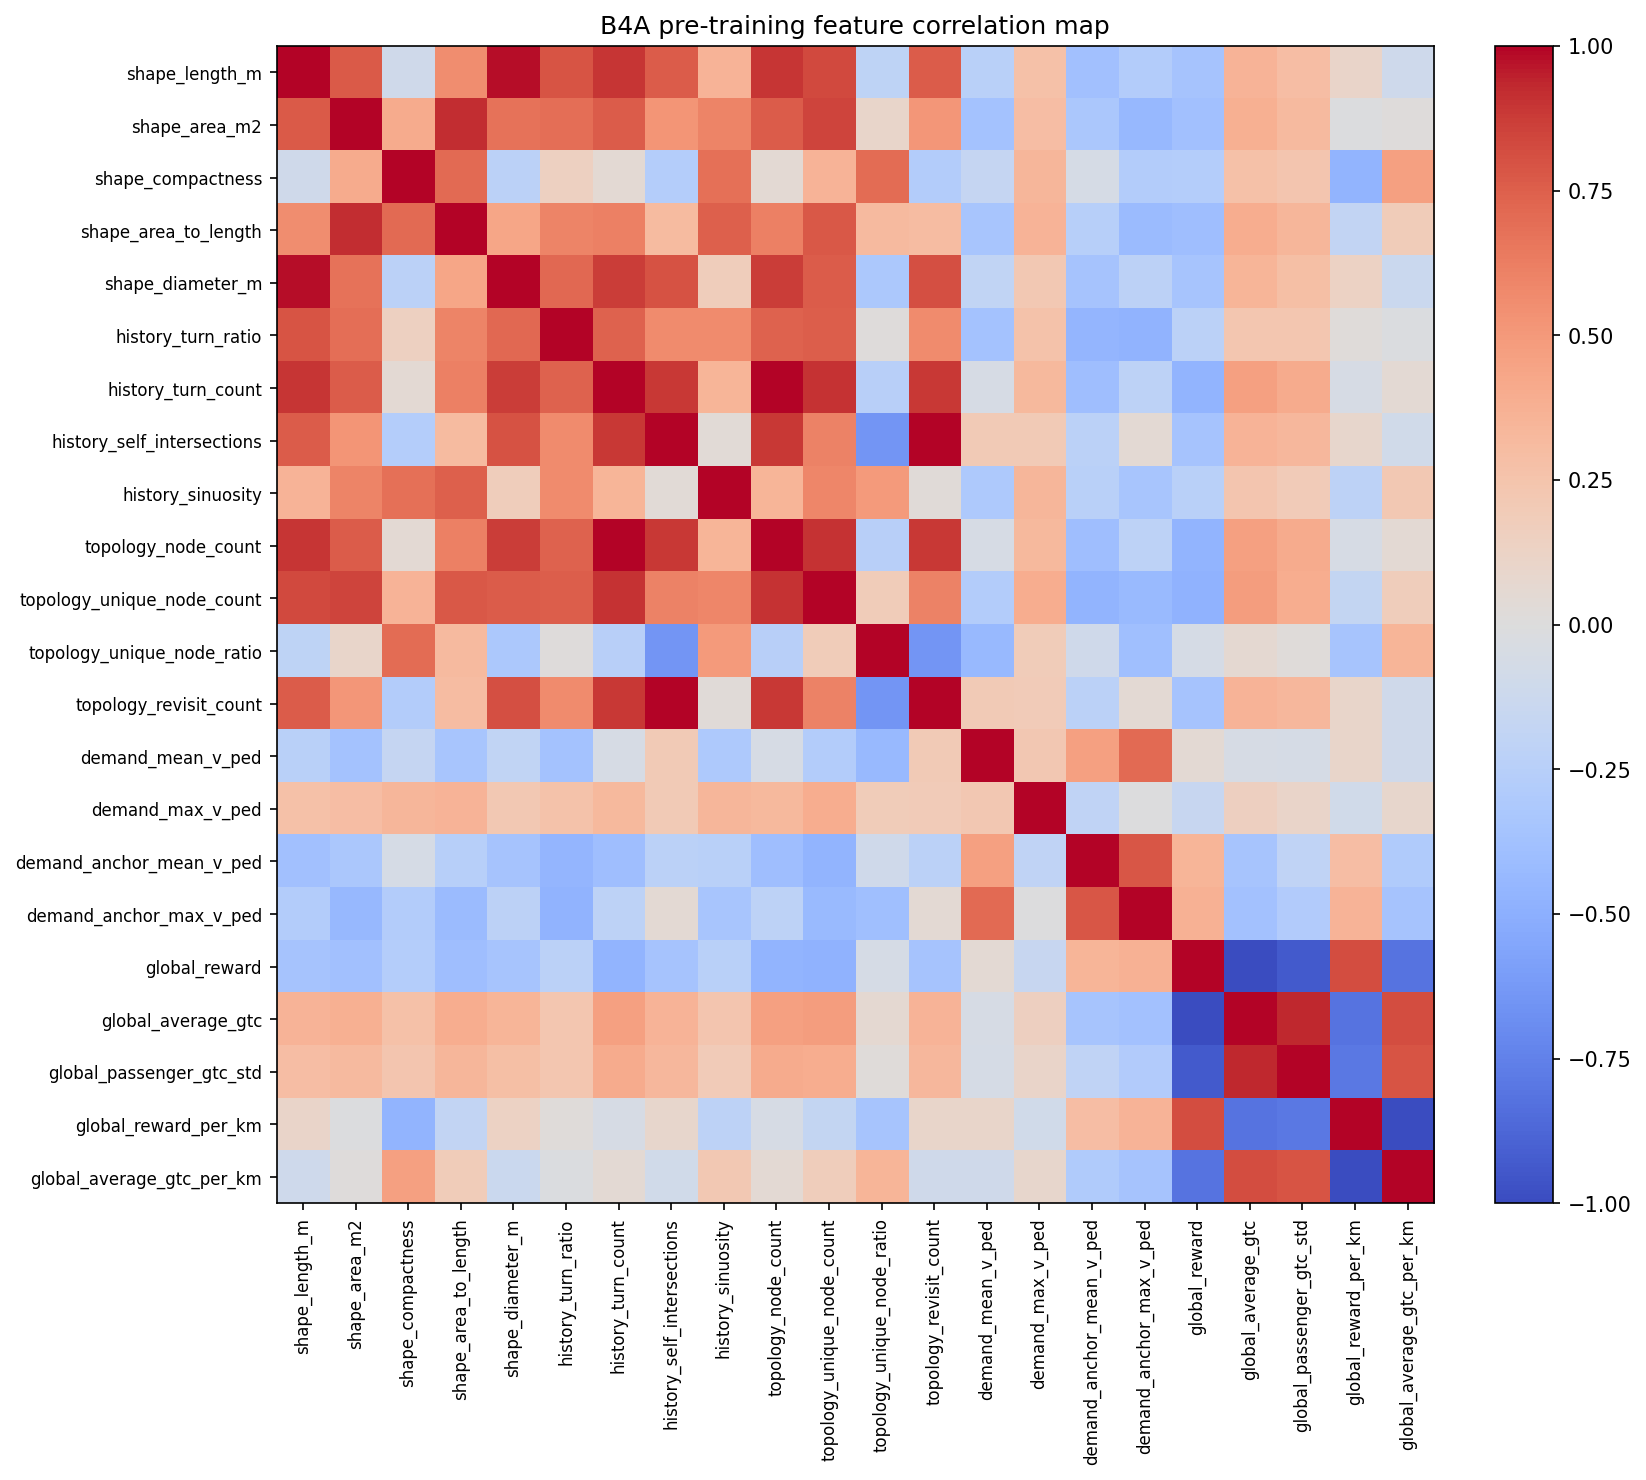

,feature_a,feature_b,correlation
0,global_reward_per_km,global_average_gtc_per_km,-1.000000
1,global_reward,global_average_gtc,-1.000000
2,history_turn_count,topology_node_count,1.000000
3,history_self_intersections,topology_revisit_count,0.999693
4,shape_length_m,shape_diameter_m,0.980016
5,global_average_gtc,global_passenger_gtc_std,0.934501
6,global_reward,global_passenger_gtc_std,-0.934501
7,shape_area_m2,shape_area_to_length,0.921498
8,history_turn_count,topology_unique_node_count,0.901099
9,topology_node_count,topology_unique_node_count,0.901099


B4A pre-training: 20 routes
means | reward=-6737.725, avg_gtc=6737.725, gtc_std=9887.564, length_m=46789.6, area_m2=31116743.3
spread | reward_std=6426.104, avg_gtc_std=6426.104, sinuosity_mean=2.652, demand_mean=1.683
top | global_reward: global_average_gtc (-1.00), global_passenger_gtc_std (-0.93), global_reward_per_km (+0.82)
top | global_average_gtc: global_reward (-1.00), global_passenger_gtc_std (+0.93), global_reward_per_km (-0.82)
top | global_passenger_gtc_std: global_reward (-0.93), global_average_gtc (+0.93), global_reward_per_km (-0.79)


In [4]:
display(Image(filename=str(pre_corr_png)))
display(pre_corr_pairs)
print(pre_summary)


## 5. Initial-run observations and key insights
The first B4A pass gives a useful baseline for the untrained route spectrum.

- The 20 generated routes are fairly large and spatially broad: average length is about 46.8 km and average area is about 31.1 million m².
- The mean reward is strongly negative because passenger generalized travel cost still dominates; average GTC is about 6737.7 with passenger GTC standard deviation about 9887.6.
- Route shape and topology are tightly linked in this baseline set: length tracks diameter very closely, turn count tracks node count almost perfectly, and self-intersections track revisit count almost exactly.
- Reward is effectively the inverse of average GTC here, and higher GTC variability lines up with worse reward.
- The demand proxy is present, but the strongest immediate structure in this initial run is still geometric and topological rather than demand-driven.

This is a clean reference point for B4A: it captures what the generator produces before learning and gives us a baseline to compare against once B4B starts shaping routes deliberately.
